# 🎮 Three Decades of GPUs: Market Consolidation, Memory, and Architecture Shifts

## ✨ Background

The graphics card market started out crowded. In the late 1990s, buyers could choose among cards from ATI, NVIDIA, 3dfx, Matrox, Intel, and others. Today, PC graphics is a three-way race between NVIDIA, AMD, and Intel. Along the way, GPUs went through several technology transitions:

- separate pixel and vertex shaders gave way to **unified shaders**,
- the PCI bus gave way to **AGP** and then several generations of **PCI Express**,
- graphics memory moved from SDR/DDR through **GDDR3, GDDR5, GDDR6**, and stacked **HBM**.

This notebook uses a product-level GPU specification dataset to trace these shifts.

## ♟️ About the Dataset

- **Source:** `gpu_specs_v6.csv` from [NVIDIA & AMD GPUs Full Specs](https://www.kaggle.com/datasets/alanjo/graphics-card-full-specs) on Kaggle (CC0 license), web-scraped from the [TechPowerUp GPU Database](https://www.techpowerup.com/gpu-specs/). It has 2,889 products, most released 1986–2022.
- **One row = one product (SKU)**, such as "GeForce GTX 1080" or "Radeon HD 4870". Rows are product launches, not unit sales. "Share" in this notebook always means *share of products released*, not market share by revenue or shipments.
- **Columns:** manufacturer, product name, release year, memory size (GB) and bus width (bits), GPU and memory clocks (MHz), shader/TMU/ROP counts, an integrated-GPU flag (`igp`), bus interface, memory type, and GPU chip codename.
- **Coverage:** eight manufacturers (NVIDIA, AMD, ATI, Intel, Matrox, 3dfx, XGI, and Sony). Other historical vendors such as S3, 3Dlabs, and PowerVR are not in the data. The analysis covers products released **through 2021**, the last complete year (see the release-year check below).

> **📌 A note on the dataset version.** The same Kaggle dataset also contains a newer file, version 7 (v7), with 3,056 products extending to 2025. In v7, the spec columns (clocks, shader counts, bus, memory type, the `igp` flag, and chip) are misaligned with the products they sit next to. For example, v7 lists the GeForce RTX 3090 with AMD's "Hawaii" chip and 2,560 shaders, while v6 correctly lists GA102 and 10,496 shaders. Among roughly 2,400 products found in both files, memory size agreed for nearly all of them, but the chip name agreed for only about 1%. v7 was therefore dropped, and this notebook uses v6 only. The lesson: check a "latest" dataset against things you already know before trusting it.

## ❓ Questions

1. How did the set of GPU makers consolidate, and who released the most products over time?
2. How fast have shader counts grown?
3. When did unified shaders replace separate pixel/vertex shaders?
4. How fast has graphics memory grown, and is that growth slowing down?
5. How did memory types and bus interfaces turn over, and how does the mix of integrated and discrete GPUs differ by vendor?

---

Import packages.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

In [2]:
import plotly

print(f'pandas version: {pd.__version__}')
print(f'plotly version: {plotly.__version__}')

pandas version: 3.0.6
plotly version: 7.1.0


Set a default theme for Plotly.

In [3]:
pio.templates['sans_serif'] = go.layout.Template(dict(    
    layout=go.Layout(
           font_family='Helvetica, Inter, Arial, sans-serif',
    ),
))

pio.templates.default = "simple_white+sans_serif"

## 📂 Load Data

Load `gpu_specs_v6.csv`.

In [4]:
df = pd.read_csv('gpu_specs_v6.csv')
df.head(3)

,manufacturer,productName,releaseYear,memSize,memBusWidth,gpuClock,memClock,unifiedShader,tmu,rop,pixelShader,vertexShader,igp,bus,memType,gpuChip
0,NVIDIA,GeForce RTX 4050,2023.0,8.0,128.0,1925,2250.0,3840.0,120,48,NaN,NaN,No,PCIe 4.0 x16,GDDR6,AD106
1,Intel,Arc A350M,2022.0,4.0,64.0,300,1500.0,768.0,48,24,NaN,NaN,No,PCIe 4.0 x8,GDDR6,DG2-128
2,Intel,Arc A370M,2022.0,4.0,64.0,300,1500.0,1024.0,64,32,NaN,NaN,No,PCIe 4.0 x8,GDDR6,DG2-128


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2889 entries, 0 to 2888
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   manufacturer   2889 non-null   str    
 1   productName    2889 non-null   str    
 2   releaseYear    2845 non-null   float64
 3   memSize        2477 non-null   float64
 4   memBusWidth    2477 non-null   float64
 5   gpuClock       2889 non-null   int64  
 6   memClock       2477 non-null   float64
 7   unifiedShader  2065 non-null   float64
 8   tmu            2889 non-null   int64  
 9   rop            2889 non-null   int64  
 10  pixelShader    824 non-null    float64
 11  vertexShader   824 non-null    float64
 12  igp            2889 non-null   str    
 13  bus            2889 non-null   str    
 14  memType        2889 non-null   str    
 15  gpuChip        2889 non-null   str    
dtypes: float64(7), int64(3), str(6)
memory usage: 485.9 KB


- 2,889 rows and 16 columns.
- `releaseYear` is a float because 44 release years are missing.


Check the number of missing values.

In [6]:
df_missing = df.isna().sum() \
    .to_frame(name='num_missing_values') \
    .reset_index(names=['column']) \
    .sort_values('num_missing_values', ascending=True)

df_missing

,column,num_missing_values
0,manufacturer,0
1,productName,0
5,gpuClock,0
14,memType,0
12,igp,0
13,bus,0
9,rop,0
8,tmu,0
15,gpuChip,0
2,releaseYear,44


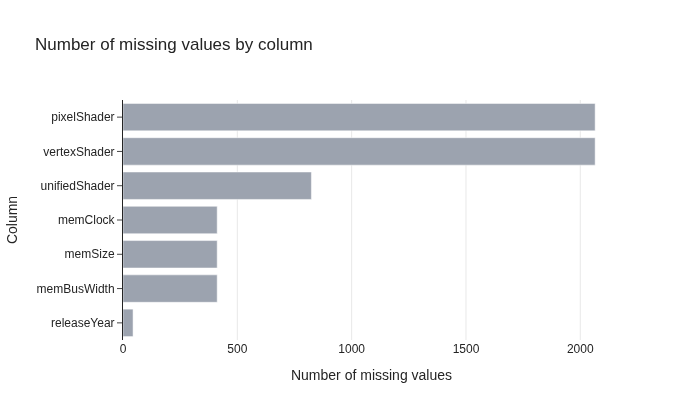

In [7]:
df_plot = df_missing.query('`num_missing_values` > 0')

fig = px.bar(
    df_plot,
    x='num_missing_values',
    y='column',
    labels={
        'num_missing_values': 'Number of missing values',
        'column': 'Column'
    },
    title='Number of missing values by column',
    height=df_plot.shape[0]*60,
)

fig.update_traces(marker_color='#9CA3AF')
fig.update_xaxes(
    showline=False,
    showgrid=True,
    linecolor='#F3F4F6',
    linewidth=1,
    ticks='',
)

fig.show()

What the missing values mean:

- **`memSize`, `memBusWidth`, `memClock`** are each missing for the same 412 rows. These are exactly the integrated GPUs (`igp` = "Yes"), which share system memory and have no memory of their own. Their `memType` is "System Shared".
- **`unifiedShader`** (824 missing) and **`pixelShader`/`vertexShader`** (2,065 missing) complement each other: 824 + 2,065 = 2,889. A GPU reports either unified shaders (newer designs) or separate pixel/vertex shaders (older designs), not both.
- **`releaseYear`** is missing for 44 rows (see below).


In [8]:
df.head(3)

,manufacturer,productName,releaseYear,memSize,memBusWidth,gpuClock,memClock,unifiedShader,tmu,rop,pixelShader,vertexShader,igp,bus,memType,gpuChip
0,NVIDIA,GeForce RTX 4050,2023.0,8.0,128.0,1925,2250.0,3840.0,120,48,NaN,NaN,No,PCIe 4.0 x16,GDDR6,AD106
1,Intel,Arc A350M,2022.0,4.0,64.0,300,1500.0,768.0,48,24,NaN,NaN,No,PCIe 4.0 x8,GDDR6,DG2-128
2,Intel,Arc A370M,2022.0,4.0,64.0,300,1500.0,1024.0,64,32,NaN,NaN,No,PCIe 4.0 x8,GDDR6,DG2-128


### 📅 Release-year coverage

`releaseYear` is stored as a float because 44 rows have no release year. What are those rows?

In [9]:
df_no_year = df[df['releaseYear'].isna()]

print(f'{df_no_year.shape[0]} products have no release year.')
df_no_year[['manufacturer', 'productName', 'memSize']].head(10)

44 products have no release year.


,manufacturer,productName,memSize
2845,ATI,FirePro V8700 Duo,1.024
2846,NVIDIA,GeForce GTX 1060 8 GB GDDR5X,8.000
2847,NVIDIA,GeForce GTX 1080 Ti 10 GB,10.000
2848,NVIDIA,GeForce GTX 470 PhysX Edition,1.280
2849,NVIDIA,GeForce GTX 470 X2,1.024
2850,NVIDIA,GeForce GTX 480 Core 512,1.536
2851,NVIDIA,GeForce GTX 490,1.536
2852,NVIDIA,GeForce GTX 780 Ti 6 GB,6.000
2853,NVIDIA,GeForce RTX 3070 Ti 16 GB,16.000
2854,NVIDIA,NVS 1000,2.000


The products without a release year look like cancelled or never-released cards, such as the GeForce GTX 490 and GeForce GTX 470 X2. They are excluded from the time-series analysis.

Next, check the most recent years.


In [10]:
num_products_recent = df['releaseYear'].value_counts().sort_index().tail(6)
num_products_recent.index = num_products_recent.index.astype(int)

num_products_recent.to_frame(name='num_products').T

releaseYear,2018,2019,2020,2021,2022,2023
num_products,93,105,86,88,57,1


In [11]:
# A few 2022 listings that do not match the products as they eventually launched
placeholder_examples = ['GeForce RTX 4060', 'GeForce RTX 4080 Ti', 'Arc A780', 'Radeon RX 7800 XT']

df.query('productName in @placeholder_examples')[['manufacturer', 'productName', 'releaseYear', 'memSize', 'gpuChip']]

,manufacturer,productName,releaseYear,memSize,gpuChip
8,Intel,Arc A780,2022.0,16.0,DG2-512
23,NVIDIA,GeForce RTX 4060,2022.0,12.0,AD104
26,NVIDIA,GeForce RTX 4080 Ti,2022.0,20.0,AD102
49,AMD,Radeon RX 7800 XT,2022.0,12.0,Navi 32


The last two years are incomplete:

- **2023** has a single product.
- **2022** has 57 products, compared with 86–105 per year in 2018–2021. It also includes pre-launch placeholders. The GeForce RTX 4080 Ti and Arc A780 never launched. The GeForce RTX 4060 is listed with 12 GB on the AD104 chip, but the card that launched in 2023 has 8 GB on AD107. The Radeon RX 7800 XT is listed with 12 GB, but it launched in 2023 with 16 GB.

All analyses therefore use products released **through 2021**, the last complete year. The 58 products from 2022–2023 are kept aside in `df_partial` and used only once, to note Intel's Arc launch. `releaseYear` is also converted to an integer.


In [12]:
# Keep the partial years aside for reference, then restrict the analysis to complete years
df_partial = df.query('releaseYear >= 2022').copy()

df = df.query('releaseYear <= 2021').copy()
df['releaseYear'] = df['releaseYear'].astype(int)

print(f"{df.shape[0]:,} products released between {df['releaseYear'].min()} and {df['releaseYear'].max()} remain.")
print(f'{df_partial.shape[0]} products from the partial years 2022–2023 are set aside.')

2,787 products released between 1986 and 2021 remain.
58 products from the partial years 2022–2023 are set aside.


## 🏁 Market Structure: Who Releases GPUs?

### Products released per year

Count the number of products by manufacturer and release year (1986–2021).

In [13]:
df_manufacturer_year = df.groupby(['manufacturer', 'releaseYear'], as_index=False).agg({
    'productName': 'count'
}).rename(columns={
    'productName': 'count'
})

df_manufacturer_year

,manufacturer,releaseYear,count
0,3dfx,1996,1
1,3dfx,1998,4
2,3dfx,1999,7
3,3dfx,2000,4
4,AMD,2006,1
...,...,...,...
107,Sony,2005,1
108,Sony,2007,2
109,Sony,2011,1
110,XGI,2003,14


Keep AMD and NVIDIA and group every other manufacturer (including ATI, which AMD acquired in 2006) into "Other".

In [14]:
df_manufacturer_year = df.copy()
df_manufacturer_year.loc[~df_manufacturer_year['manufacturer'].isin(['AMD', 'NVIDIA']), 'manufacturer'] = 'Other'

df_manufacturer_year = df_manufacturer_year.groupby(['manufacturer', 'releaseYear'], as_index=False).agg({
    'productName': 'count'
}).rename(columns={
    'productName': 'count'
})

df_manufacturer_year

,manufacturer,releaseYear,count
0,AMD,2006,1
1,AMD,2007,1
2,AMD,2008,2
3,AMD,2009,1
4,AMD,2010,18
...,...,...,...
71,Other,2017,7
72,Other,2018,9
73,Other,2019,6
74,Other,2020,13


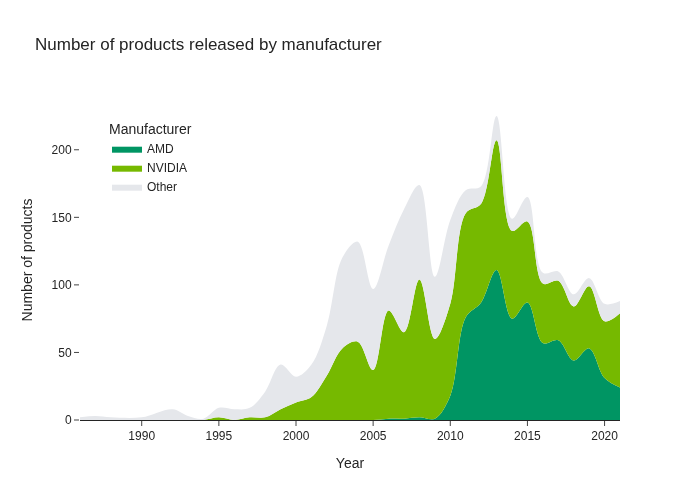

In [15]:
fig = px.area(
    df_manufacturer_year,
    x='releaseYear',
    y='count',
    color='manufacturer',
    labels={
        'count': 'Number of products',
        'releaseYear': 'Year',
        'manufacturer': 'Manufacturer',
    },
    title='Number of products released by manufacturer',
    color_discrete_map={
        'AMD': '#009563',
        'NVIDIA': '#76b900',
        'Other': '#E5E7EB',
    },
    line_shape='spline',
    height=500,
)

fig.for_each_trace(lambda trace: trace.update(fillcolor = trace.line.color))
fig.update_yaxes(showline=False)
fig.update_traces(line={'width': 0})
fig.update_layout(
    hovermode='x',
    legend=dict(
        yanchor='top',
        xanchor='left',
        y=0.95,
        x=0.05
    )
)

fig.show()

In [16]:
num_products_per_year = df.groupby('releaseYear').size()

print(f'Peak year: {num_products_per_year.idxmax()} ({num_products_per_year.max()} products)')
print(f'Products per year, 2017–2021: {num_products_per_year.loc[2017:2021].to_dict()}')

Peak year: 2013 (225 products)
Products per year, 2017–2021: {2017: 110, 2018: 93, 2019: 105, 2020: 86, 2021: 88}


- Product launches peaked in **2013 at 225 products**. In 2017–2021 the count ranged from 86 to 110 per year. The vendors release fewer distinct SKUs than they did in the early 2010s.
- Before 2010, most of the gray "Other" area is **ATI**. AMD bought ATI in 2006, but the dataset kept the ATI label on most Radeon products until 2010. AMD's sudden "arrival" in 2010 is mostly a relabeling. The next chart shows ATI separately.


### Share of products released by manufacturer (since 1995)

Compute each manufacturer's share of the products released in each year. ATI is shaded as a lighter version of AMD's color because AMD acquired ATI in 2006 and kept selling ATI-branded Radeon and FirePro cards for a few more years.

In [17]:
df_manufacturer_year_1995 = df.copy()
df_manufacturer_year_1995 =df_manufacturer_year_1995.query('releaseYear >= 1995')

df_manufacturer_year_1995 = df_manufacturer_year_1995.groupby(['manufacturer', 'releaseYear'], as_index=False).agg({
    'productName': 'count'
}).rename(columns={
    'productName': 'count'
})

df_manufacturer_year_1995['year_percentage'] = df_manufacturer_year_1995['count'] / \
    df_manufacturer_year_1995.groupby('releaseYear')['count'].transform('sum')

df_manufacturer_year_1995

,manufacturer,releaseYear,count,year_percentage
0,3dfx,1996,1,0.125000
1,3dfx,1998,4,0.190476
2,3dfx,1999,7,0.170732
3,3dfx,2000,4,0.125000
4,AMD,2006,1,0.007752
...,...,...,...,...
100,Sony,2005,1,0.010309
101,Sony,2007,2,0.012821
102,Sony,2011,1,0.005882
103,XGI,2003,14,0.116667


In [18]:
list(reversed(['NVIDIA', 'Intel', 'XGI', 'Sony', 'Matrox', '3dfx', 'ATI', 'AMD']))

['AMD', 'ATI', '3dfx', 'Matrox', 'Sony', 'XGI', 'Intel', 'NVIDIA']

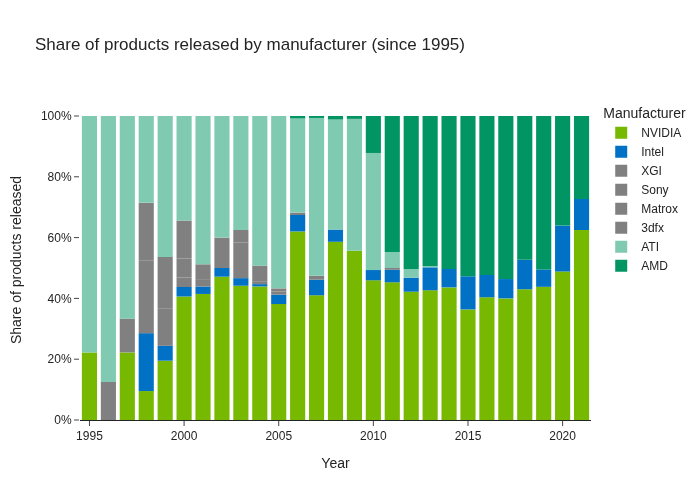

In [19]:
fig = px.bar(
    df_manufacturer_year_1995,
    x='releaseYear',
    y='year_percentage',
    color='manufacturer',
    labels={
        'count': 'Number of products',
        'year_percentage': 'Share of products released',
        'releaseYear': 'Year',
        'manufacturer': 'Manufacturer',
    },
    title='Share of products released by manufacturer (since 1995)',
    color_discrete_map={
        'AMD': '#009563',
        'ATI': '#80CAB1',
        '3dfx': 'gray',
        'Matrox': 'gray',
        'Sony': 'gray',
        'XGI': 'gray',
        'Intel': '#0071C5',
        'NVIDIA': '#76b900',
    },
    category_orders={
        'manufacturer': reversed(['AMD', 'ATI', '3dfx', 'Matrox', 
                                  'Sony', 'XGI', 'Intel', 'NVIDIA'])
    },
    height=500,
)

fig.update_yaxes(
    showline=False,
    tickformat='.0%',
)


fig.update_traces(marker=dict(line_width=0))

fig.show()

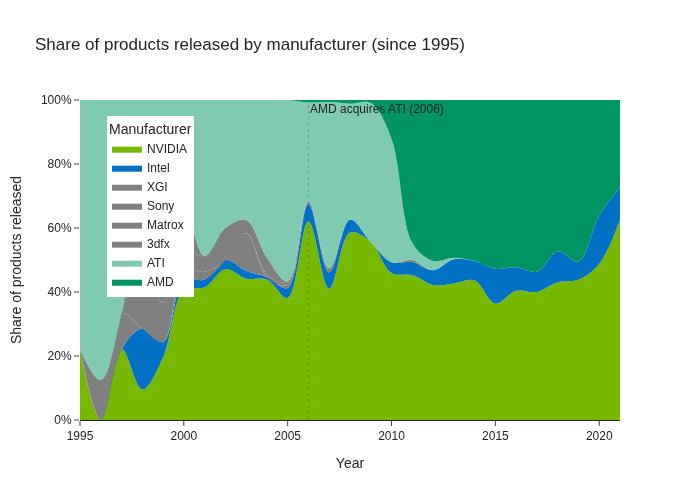

In [20]:
fig = px.area(
    df_manufacturer_year_1995,
    x='releaseYear',
    y='year_percentage',
    color='manufacturer',
    labels={
        'count': 'Number of products',
        'year_percentage': 'Share of products released',
        'releaseYear': 'Year',
        'manufacturer': 'Manufacturer',
    },
    title='Share of products released by manufacturer (since 1995)',
    color_discrete_map={
        'AMD': '#009563',
        'ATI': '#80CAB1',
        '3dfx': 'gray',
        'Matrox': 'gray',
        'Sony': 'gray',
        'XGI': 'gray',
        'Intel': '#0071C5',
        'NVIDIA': '#76b900',
    },
    category_orders={
        'manufacturer': reversed(['AMD', 'ATI', '3dfx', 'Matrox', 
                                  'Sony', 'XGI', 'Intel', 'NVIDIA'])
    },
    line_shape='spline',
    height=500,
)

fig.for_each_trace(lambda trace: trace.update(fillcolor = trace.line.color))
fig.update_yaxes(showline=False, tickformat='.0%')
fig.update_traces(line={'width': 0})
fig.update_layout(
    hovermode='x',
    legend=dict(
        yanchor='top',
        xanchor='left',
        y=0.95,
        x=0.05
    ),
    yaxis_range=[0, 1]
)
fig.add_vline(
    x=2006,
    line_dash='dot',
    line_color='#374151',
    line_width=1,
    annotation_text='AMD acquires ATI (2006)',
    annotation_position='top right',
)
fig.show()

Summarize the shares by era, folding ATI into AMD.

In [21]:
df_era = df.query('releaseYear >= 1995').copy()
df_era['vendor'] = df_era['manufacturer'].replace({'ATI': 'AMD'})
df_era.loc[~df_era['vendor'].isin(['AMD', 'NVIDIA', 'Intel']), 'vendor'] = 'Other'
df_era['era'] = pd.cut(
    df_era['releaseYear'],
    bins=[1994, 1999, 2005, 2010, 2015, 2021],
    labels=['1995–1999', '2000–2005', '2006–2010', '2011–2015', '2016–2021'],
)

vendor_labels = {'AMD': 'AMD + ATI (%)', 'NVIDIA': 'NVIDIA (%)', 'Intel': 'Intel (%)', 'Other': 'Other (%)'}
vendor_columns = ['NVIDIA (%)', 'AMD + ATI (%)', 'Intel (%)', 'Other (%)']

df_era_share = pd.crosstab(df_era['era'], df_era['vendor'], normalize='index') \
    .mul(100) \
    .round(1) \
    .rename(columns=vendor_labels)
df_era_share['num_products'] = df_era['era'].value_counts().sort_index()

df_era_share[vendor_columns + ['num_products']]

vendor,NVIDIA (%),AMD + ATI (%),Intel (%),Other (%),num_products
era,,,,,
1995–1999,15.9,51.1,6.8,26.1,88
2000–2005,42.9,45.5,2.2,9.3,492
2006–2010,52.3,43.5,3.8,0.4,713
2011–2015,42.1,51.1,6.7,0.1,882
2016–2021,45.9,45.3,8.8,0.0,591


In [22]:
# The most recent complete years
pd.crosstab(df_era['releaseYear'], df_era['vendor'], normalize='index') \
    .mul(100) \
    .round(1) \
    .rename(columns=vendor_labels) \
    .loc[2018:2021, vendor_columns]

vendor,NVIDIA (%),AMD + ATI (%),Intel (%),Other (%)
releaseYear,,,,
2018,43.0,47.3,9.7,0.0
2019,43.8,50.5,5.7,0.0
2020,48.8,36.0,15.1,0.0
2021,62.5,27.3,10.2,0.0


- **AMD (with ATI) and NVIDIA have split the product catalog for over 20 years.** In every era from 2000 to 2021, NVIDIA released 42.1%–52.3% of products and AMD + ATI 43.5%–51.1%.
- The early field was diverse. In 1995–1999, "Other" vendors (3dfx, Matrox, Sony) accounted for 26.1% of products. By 2006–2010 they were down to 0.4%.
- **The balance tilted toward NVIDIA at the end of the period.** NVIDIA released 62.5% of the products in 2021, compared with 27.3% for AMD. Intel's share was 2.2%–8.8% per era and peaked at 15.1% in 2020.
- The early years (1995–1999) contain only 88 products, so their year-to-year swings are noisy.


### Vendor entries and exits

When did each manufacturer release its first and last product in the dataset?

In [23]:
df_vendor_span = df.groupby('manufacturer', as_index=False).agg(
    first_year=('releaseYear', 'min'),
    last_year=('releaseYear', 'max'),
    num_products=('productName', 'count'),
).sort_values('first_year')

df_vendor_span

,manufacturer,first_year,last_year,num_products
2,ATI,1986,2013,591
6,Sony,1994,2011,9
5,NVIDIA,1995,2021,1240
0,3dfx,1996,2000,16
4,Matrox,1998,2006,34
3,Intel,1998,2021,155
7,XGI,2003,2005,15
1,AMD,2006,2021,727


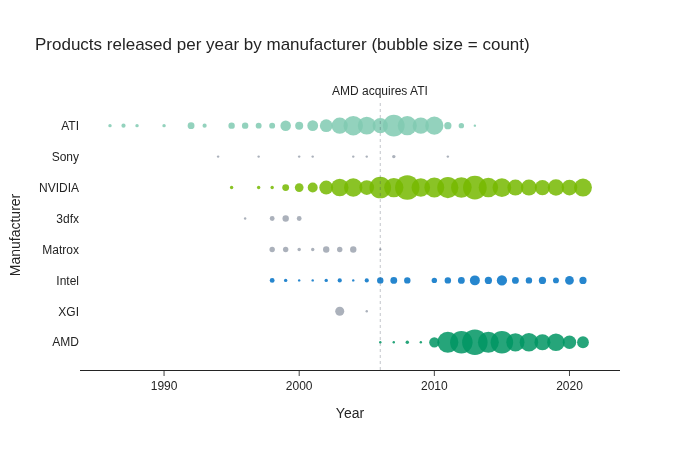

In [24]:
df_vendor_year = df.groupby(['manufacturer', 'releaseYear'], as_index=False).agg({
    'productName': 'count'
}).rename(columns={
    'productName': 'count'
})

vendor_colors = {
    'NVIDIA': '#76b900',
    'AMD': '#009563',
    'ATI': '#80CAB1',
    'Intel': '#0071C5',
    '3dfx': '#9CA3AF',
    'Matrox': '#9CA3AF',
    'Sony': '#9CA3AF',
    'XGI': '#9CA3AF',
}

fig = px.scatter(
    df_vendor_year,
    x='releaseYear',
    y='manufacturer',
    size='count',
    color='manufacturer',
    color_discrete_map=vendor_colors,
    category_orders={
        'manufacturer': list(df_vendor_span['manufacturer'])
    },
    labels={
        'releaseYear': 'Year',
        'manufacturer': 'Manufacturer',
        'count': 'Number of products',
    },
    title='Products released per year by manufacturer (bubble size = count)',
    size_max=18,
    height=450,
)

fig.update_traces(marker={'line_width': 0, 'opacity': 0.85})
fig.update_layout(showlegend=False)
fig.update_yaxes(showline=False, ticks='')
fig.add_vline(
    x=2006,
    line_dash='dot',
    line_color='#374151',
    line_width=1,
    annotation_text='AMD acquires ATI',
    annotation_position='top',
)

fig.show()

In [25]:
# Count a manufacturer as active in a year if it released at least one product that year.
# ATI products released after the 2006 acquisition are counted under AMD.
df_company = df.copy()
df_company['company'] = df_company['manufacturer'].mask(
    (df_company['manufacturer'] == 'ATI') & (df_company['releaseYear'] >= 2006), 'AMD'
)
num_active_companies = df_company.groupby('releaseYear')['company'].nunique()

print(f'Most active manufacturers in one year: {num_active_companies.max()} '
      f'(in {list(num_active_companies[num_active_companies == num_active_companies.max()].index)})')
print(f'Active manufacturers by year, 2005–2021: {num_active_companies.loc[2005:].to_dict()}')

Most active manufacturers in one year: 6 (in [2000])
Active manufacturers by year, 2005–2021: {2005: 5, 2006: 4, 2007: 4, 2008: 3, 2009: 2, 2010: 3, 2011: 4, 2012: 3, 2013: 3, 2014: 3, 2015: 3, 2016: 3, 2017: 3, 2018: 3, 2019: 3, 2020: 3, 2021: 3}


- In 2000, six manufacturers in the dataset released at least one product. **From 2012 to 2021, every year had exactly three: NVIDIA, AMD, and Intel.** (2009 has only two because the data has no Intel product dated 2009. 2011 has four because of Sony's PlayStation Vita GPU.)
- Exits: **3dfx** released its last product in 2000 (NVIDIA bought 3dfx's assets at the end of that year), **XGI** appears only in 2003–2005, and **Matrox** last appears in 2006.
- **ATI** products continue to appear until 2013 because the ATI brand outlived the 2006 acquisition.
- This count reflects the dataset's coverage of eight manufacturers. The real market of the late 1990s had more players (S3, 3Dlabs, PowerVR, and others), so the actual consolidation was even larger than shown here.


## 🧮 How Fast Have Shader Counts Grown?

Shaders are the programmable cores that do most of a GPU's work. The next three charts plot the number of unified shaders in each product released from 2010 to 2021, with a LOWESS trend line: first for all manufacturers, then as a box plot by year, and finally AMD vs. NVIDIA side by side.

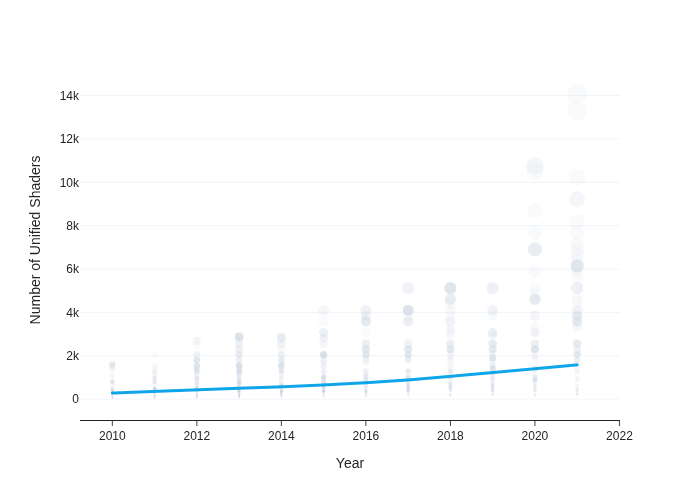

In [26]:
df_p2010 = df.query('releaseYear >= 2010')
df_p2010 = df_p2010.dropna(subset=['unifiedShader'])

fig = px.scatter(
    df_p2010,
    x='releaseYear',
    y='unifiedShader',
    size='unifiedShader',
    trendline="lowess",
    labels={
        'unifiedShader': 'Number of Unified Shaders',
        'releaseYear': 'Year',
    },
    hover_name='productName',
    height=500,
)

# fig.update_layout(yaxis_title='Number of Unified Shaders')
fig.update_yaxes(showline=False, showgrid=True, gridcolor='#F1F5F9', ticks='')
fig.update_traces(
    marker={
        'color': '#CBD5E1',
        'opacity': 0.1,
        'line_width': 0,
    },
    line={
        'color': '#0EA5E9',
        'width': 3,
    }
)

fig.show()

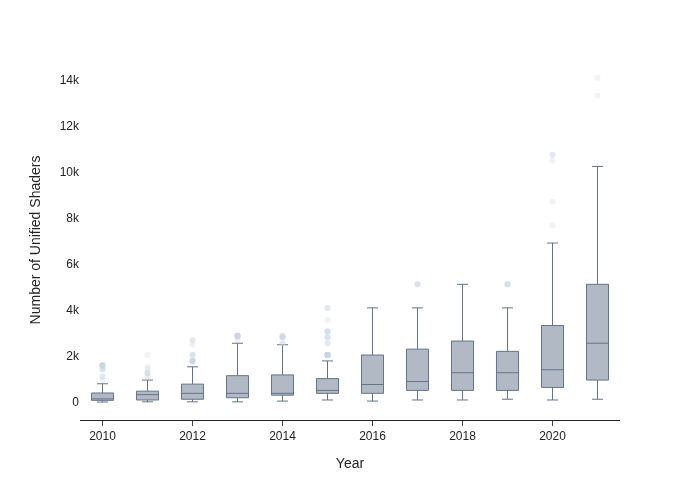

In [27]:
df_p2010 = df.query('releaseYear >= 2010')
df_p2010 = df_p2010.dropna(subset=['unifiedShader'])

fig = px.box(
    df_p2010,
    x='releaseYear',
    y='unifiedShader',
    labels={
        'unifiedShader': 'Number of Unified Shaders',
        'releaseYear': 'Year',
    },
    height=500,
)

fig.update_xaxes(
    # showline=False,
)
fig.update_yaxes(
    showline=False,
    ticks='',
)

fig.update_traces(
    marker={
        'color': '#CBD5E1',
        'opacity': 0.3,
        'line_width': 0,
    },
    line={
        'color': '#64748B',
        'width': 1,
    }
)

fig.show()

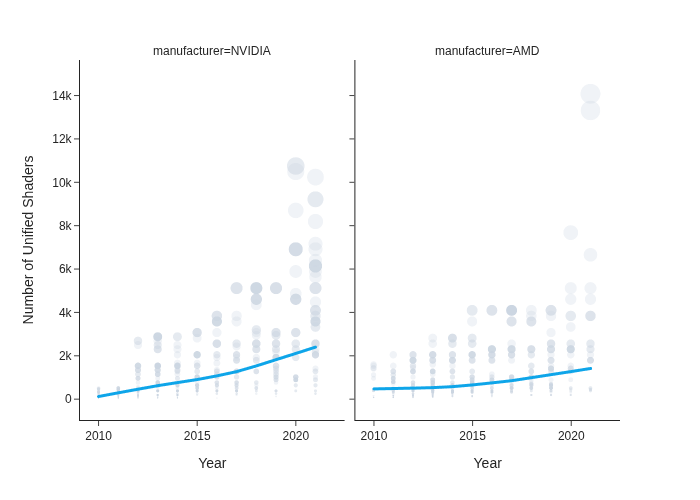

In [28]:
df_p2010_2 = df.query('releaseYear >= 2010')
df_p2010_2 = df_p2010_2[df_p2010_2['manufacturer'].isin(['AMD', 'NVIDIA'])]
df_p2010_2 = df_p2010_2.dropna(subset=['unifiedShader'])

fig = px.scatter(
    df_p2010_2,
    x='releaseYear',
    y='unifiedShader',
    size='unifiedShader',
    facet_col='manufacturer',
    trendline="lowess",
    labels={
        'unifiedShader': 'Number of Unified Shaders',
        'releaseYear': 'Year',
    },
    hover_name='productName',
    height=500,
)

# fig.update_layout(yaxis_title='Number of Unified Shaders')
fig.update_traces(
    marker={
        'color': '#CBD5E1',
        'opacity': 0.3,
        'line_width': 0,
    },
    line={
        'color': '#0EA5E9',
        'width': 3,
    }
)

fig.show()

In [29]:
df_shaders = df.dropna(subset=['unifiedShader']).query('releaseYear >= 2010')

df_shader_year = df_shaders \
    .groupby('releaseYear', as_index=False) \
    .agg(
        median_shaders=('unifiedShader', 'median'),
        max_shaders=('unifiedShader', 'max'),
        share_under_1000=('unifiedShader', lambda x: (x < 1000).mean()),
        num_products=('unifiedShader', 'count'),
    )

df_shader_year['max_product'] = df_shaders.loc[
    df_shaders.groupby('releaseYear')['unifiedShader'].idxmax(), 'productName'
].values

slope_median = np.polyfit(df_shader_year['releaseYear'], np.log2(df_shader_year['median_shaders']), deg=1)[0]
slope_max = np.polyfit(df_shader_year['releaseYear'], np.log2(df_shader_year['max_shaders']), deg=1)[0]
print(f'Median shader count doubles every {1 / slope_median:.1f} years (2010–2021)')
print(f'Maximum shader count doubles every {1 / slope_max:.1f} years (2010–2021)')

df_shader_year.query('releaseYear in [2010, 2013, 2016, 2017, 2018, 2019, 2020, 2021]').round(2)

Median shader count doubles every 3.2 years (2010–2021)
Maximum shader count doubles every 4.1 years (2010–2021)


,releaseYear,median_shaders,max_shaders,share_under_1000,num_products,max_product
0,2010,144.0,1600.0,0.92,146,FirePro V8800
3,2013,384.0,2880.0,0.75,222,GeForce GTX 780 Ti
6,2016,768.0,4096.0,0.57,109,FirePro S9300 X2
7,2017,896.0,5120.0,0.53,110,Tesla V100 PCIe 16 GB
8,2018,1280.0,5120.0,0.43,93,Quadro GV100
9,2019,1280.0,5120.0,0.44,105,Tesla PG500-216
10,2020,1408.0,10752.0,0.40,86,A40 PCIe
11,2021,2560.0,14080.0,0.25,88,Radeon Instinct MI250X


In [30]:
df.query('releaseYear >= 2010 and manufacturer in ["AMD", "NVIDIA"]') \
    .pivot_table(index='manufacturer', columns='releaseYear', values='unifiedShader', aggfunc='median') \
    .loc[:, [2010, 2013, 2016, 2019, 2020, 2021]]

releaseYear,2010,2013,2016,2019,2020,2021
manufacturer,,,,,,
AMD,400.0,384.0,768.0,704.0,2048.0,2176.0
NVIDIA,96.0,384.0,1152.0,1536.0,2432.0,3584.0


- **Shader counts grew steadily rather than jumping in one step.** The median product went from 144 unified shaders in 2010 to 2,560 in 2021, doubling about every **3.2 years**. The largest count went from 1,600 to 14,080 (the Radeon Instinct MI250X), doubling about every 4.1 years.
- **The spread widened.** In 2010, 92% of products had fewer than 1,000 shaders. By 2021 that share was down to 25%, and the box plot's interquartile range had grown from a few hundred shaders to several thousand. The maximum stayed at 5,120 from 2017 to 2019 and then doubled twice in two years, so counts above 10,000 appear only in 2020–2021.
- The LOWESS line smooths across neighboring years, so it sits below the 2021 median and understates the late acceleration.
- **AMD vs. NVIDIA:** NVIDIA's median rose faster (96 → 3,584 from 2010 to 2021, compared with 400 → 2,176 for AMD). Treat cross-vendor comparisons with care. A "shader" is not the same unit across vendors or architectures. For example, NVIDIA's 2020 Ampere generation doubled the number of FP32 units it counts per streaming multiprocessor, which contributes to the 2020 jump.


## 🧬 When Did Unified Shaders Replace Separate Pixel/Vertex Shaders?

Older GPUs had separate units for vertex and pixel processing (or fixed-function pipelines). Unified shader architectures, which arrived with the DirectX 10 generation, use one pool of programmable shaders for both. In the data, a product has either a `unifiedShader` count or `pixelShader`/`vertexShader` counts.

In [31]:
df_1995 = df.query('releaseYear >= 1995').copy()
df_1995['shaderArchitecture'] = np.where(
    df_1995['unifiedShader'].notna(),
    'Unified shaders',
    'Separate pixel/vertex shaders',
)

df_arch = df_1995.query('releaseYear >= 1998 and releaseYear <= 2012') \
    .groupby(['releaseYear', 'shaderArchitecture'], as_index=False) \
    .agg({'productName': 'count'}) \
    .rename(columns={'productName': 'count'})
df_arch['share'] = df_arch['count'] / df_arch.groupby('releaseYear')['count'].transform('sum')

df_arch.query('releaseYear >= 2005 and releaseYear <= 2010') \
    .pivot(index='shaderArchitecture', columns='releaseYear', values='count') \
    .fillna(0) \
    .astype(int)

releaseYear,2005,2006,2007,2008,2009,2010
shaderArchitecture,,,,,,
Separate pixel/vertex shaders,96,127,62,9,0,2
Unified shaders,1,2,94,165,106,146


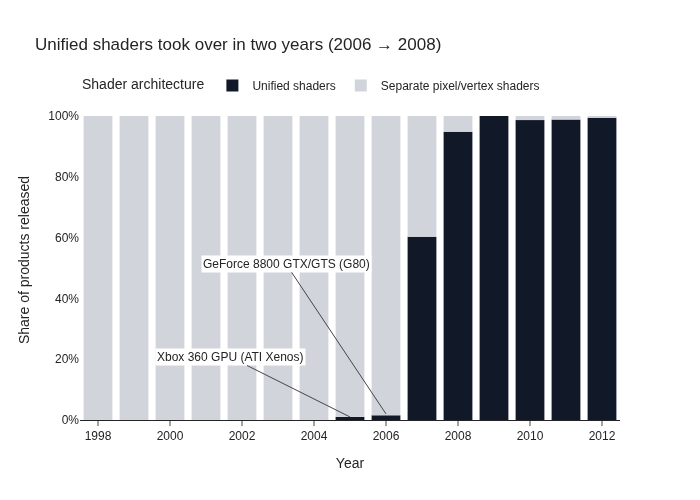

In [32]:
fig = px.bar(
    df_arch,
    x='releaseYear',
    y='share',
    color='shaderArchitecture',
    color_discrete_map={
        'Unified shaders': '#111827',
        'Separate pixel/vertex shaders': '#D1D5DB',
    },
    category_orders={
        'shaderArchitecture': ['Unified shaders', 'Separate pixel/vertex shaders']
    },
    labels={
        'releaseYear': 'Year',
        'share': 'Share of products released',
        'shaderArchitecture': 'Shader architecture',
    },
    title='Unified shaders took over in two years (2006 → 2008)',
    height=500,
)

fig.update_traces(marker_line_width=0)
fig.update_yaxes(showline=False, tickformat='.0%', ticks='')
fig.update_layout(legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='left', x=0))
fig.add_annotation(
    x=2006,
    y=0.02,
    text='GeForce 8800 GTX/GTS (G80)',
    showarrow=True,
    arrowhead=0,
    ax=-100,
    ay=-150,
    bgcolor='white',
    font={'size': 12},
)
fig.add_annotation(
    x=2005,
    y=0.01,
    text='Xbox 360 GPU (ATI Xenos)',
    showarrow=True,
    arrowhead=0,
    ax=-120,
    ay=-60,
    bgcolor='white',
    font={'size': 12},
)

fig.show()

In [33]:
df_1995.query('shaderArchitecture == "Unified shaders"') \
    .nsmallest(5, 'releaseYear')[['manufacturer', 'productName', 'releaseYear', 'unifiedShader', 'gpuChip']]

,manufacturer,productName,releaseYear,unifiedShader,gpuChip
2340,ATI,Xbox 360 GPU 90nm,2005,240.0,Xenos Xenon
2157,NVIDIA,GeForce 8800 GTS 640,2006,96.0,G80
2158,NVIDIA,GeForce 8800 GTX,2006,128.0,G80
1960,ATI,FireGL V3600,2007,120.0,RV630
1961,ATI,FireGL V5600,2007,120.0,RV630


In [34]:
df_1995.query('releaseYear >= 2009 and shaderArchitecture == "Separate pixel/vertex shaders"')[
    ['manufacturer', 'productName', 'releaseYear', 'pixelShader', 'vertexShader']
]

,manufacturer,productName,releaseYear,pixelShader,vertexShader
1054,NVIDIA,Playstation 3 GPU 28nm,2013,24.0,8.0
1173,NVIDIA,Tegra 4 GPU,2013,48.0,24.0
1174,NVIDIA,Tegra 4i GPU,2013,48.0,12.0
1271,NVIDIA,Playstation 3 GPU 40nm,2012,24.0,8.0
1428,Sony,Playstation Vita GPU,2011,4.0,2.0
1518,NVIDIA,Tegra 3 GPU,2011,8.0,4.0
1605,Intel,GMA,2010,4.0,2.0
1677,NVIDIA,Tegra 2 GPU,2010,4.0,4.0


- **The switch to unified shaders took about two years.** In 2006 only 2 of 129 products (1.6%) had unified shaders. In 2007 it was 94 of 156 (60%), in 2008 165 of 174 (95%), and in 2009 every product.
- **A game console came first.** The earliest unified-shader GPU in the data is the **Xbox 360 GPU** (ATI's Xenos, 2005). The first PC cards were NVIDIA's GeForce 8800 GTX/GTS (G80) in 2006.
- **The holdouts after 2009 are all mobile or console chips**: NVIDIA Tegra 2/3/4, die-shrunk PlayStation 3 GPUs, the PlayStation Vita GPU, and one Intel GMA part.


## 💾 How Fast Has Graphics Memory Grown?

Integrated GPUs have no memory of their own (they share system memory), so they drop out of this section. The analysis covers 1995–2021.

In [35]:
import statsmodels.formula.api as smf

df_mem = df.dropna(subset=['memSize']).query('releaseYear >= 1995')

df_mem_year = df_mem.groupby('releaseYear', as_index=False).agg(
    median_mem=('memSize', 'median'),
    max_mem=('memSize', 'max'),
    num_products=('memSize', 'count'),
)
df_mem_year['log2_median_mem'] = np.log2(df_mem_year['median_mem'])
df_mem_year['max_to_median'] = df_mem_year['max_mem'] / df_mem_year['median_mem']

# Product holding the largest memory in each year (for annotations)
df_mem_year['max_product'] = df_mem.loc[
    df_mem.groupby('releaseYear')['memSize'].idxmax(), 'productName'
].values

df_mem_year.query('releaseYear in [2000, 2005, 2010, 2015, 2020, 2021]')

,releaseYear,median_mem,max_mem,num_products,log2_median_mem,max_to_median,max_product
5,2000,0.032,0.128,31,-4.965784,4.000000,Fire GL3
10,2005,0.256,1.024,88,-1.965784,4.000000,FireGL V7350
15,2010,1.024,6.000,133,0.034216,5.859375,Quadro 6000
20,2015,2.000,32.000,135,1.000000,16.000000,FirePro S9170
25,2020,8.000,80.000,68,3.000000,10.000000,A100 SXM4 80 GB
26,2021,9.000,128.000,74,3.169925,14.222222,Radeon Instinct MI250


In [36]:
# Piecewise log-linear trend: does the doubling time change after 2010?
df_mem_year['post_2010'] = (df_mem_year['releaseYear'] >= 2010).astype(int)
model_mem = smf.ols('log2_median_mem ~ releaseYear * post_2010', data=df_mem_year).fit()

slope_pre = model_mem.params['releaseYear']
slope_post = slope_pre + model_mem.params['releaseYear:post_2010']
print(f'Median memory doubling time, 1995–2009: {1 / slope_pre:.1f} years')
print(f'Median memory doubling time, 2010–2021: {1 / slope_post:.1f} years')
print(f"p-value for the change in slope: {model_mem.pvalues['releaseYear:post_2010']:.1e}")

# Robustness: product-level regression and other break years
df_mem_model = df_mem.assign(
    log2_mem=np.log2(df_mem['memSize']),
    post_2010=(df_mem['releaseYear'] >= 2010).astype(int),
)
model_mem_products = smf.ols('log2_mem ~ releaseYear * post_2010', data=df_mem_model).fit()
slope_pre_p = model_mem_products.params['releaseYear']
slope_post_p = slope_pre_p + model_mem_products.params['releaseYear:post_2010']
print(f'Product-level fit: {1 / slope_pre_p:.1f} years before 2010 vs. {1 / slope_post_p:.1f} years from 2010')

robustness_rows = []
for break_year in range(2006, 2013):
    df_tmp = df_mem_year.assign(post=(df_mem_year['releaseYear'] >= break_year).astype(int))
    m = smf.ols('log2_median_mem ~ releaseYear * post', data=df_tmp).fit()
    s_pre = m.params['releaseYear']
    s_post = s_pre + m.params['releaseYear:post']
    robustness_rows.append({
        'break_year': break_year,
        'doubling_years_before': round(1 / s_pre, 2),
        'doubling_years_after': round(1 / s_post, 2),
    })

pd.DataFrame(robustness_rows).set_index('break_year').T

Median memory doubling time, 1995–2009: 1.7 years
Median memory doubling time, 2010–2021: 3.1 years
p-value for the change in slope: 8.3e-06
Product-level fit: 1.9 years before 2010 vs. 3.2 years from 2010


break_year,2006,2007,2008,2009,2010,2011,2012
doubling_years_before,1.38,1.45,1.55,1.60,1.67,1.70,1.75
doubling_years_after,2.82,2.84,2.98,2.98,3.11,2.98,2.97


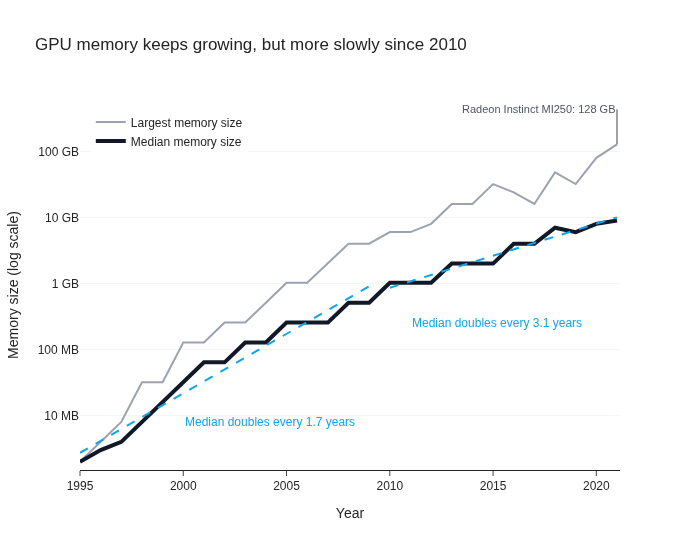

In [37]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_mem_year['releaseYear'],
    y=df_mem_year['max_mem'],
    name='Largest memory size',
    mode='lines',
    line={'color': '#9CA3AF', 'width': 2},
    customdata=df_mem_year['max_product'],
    hovertemplate='%{x}: %{y} GB (%{customdata})<extra></extra>',
))
fig.add_trace(go.Scatter(
    x=df_mem_year['releaseYear'],
    y=df_mem_year['median_mem'],
    name='Median memory size',
    mode='lines',
    line={'color': '#111827', 'width': 4},
    hovertemplate='%{x}: %{y} GB<extra></extra>',
))

# Fitted trend lines for the two eras
for is_post, label in [(0, '1995–2009 trend'), (1, '2010–2021 trend')]:
    df_era_fit = df_mem_year.query('post_2010 == @is_post')
    fig.add_trace(go.Scatter(
        x=df_era_fit['releaseYear'],
        y=2 ** model_mem.predict(df_era_fit),
        name=label,
        mode='lines',
        line={'color': '#0EA5E9', 'width': 2, 'dash': 'dash'},
        showlegend=False,
        hoverinfo='skip',
    ))

fig.add_annotation(x=2000, y=np.log10(0.008), text=f'Median doubles every {1 / slope_pre:.1f} years',
                   showarrow=False, font={'color': '#0EA5E9'}, xanchor='left')
fig.add_annotation(x=2011, y=np.log10(0.25), text=f'Median doubles every {1 / slope_post:.1f} years',
                   showarrow=False, font={'color': '#0EA5E9'}, xanchor='left')
row_max = df_mem_year.iloc[-1]
fig.add_annotation(x=row_max['releaseYear'], y=np.log10(row_max['max_mem']),
                   text=f"{row_max['max_product']}: {row_max['max_mem']:.0f} GB",
                   showarrow=True, arrowhead=0, ax=0, ay=-35, xanchor='right', font={'size': 11, 'color': '#4B5563'})

fig.update_yaxes(
    type='log',
    tickvals=[0.001, 0.01, 0.1, 1, 10, 100],
    ticktext=['1 MB', '10 MB', '100 MB', '1 GB', '10 GB', '100 GB'],
    range=[np.log10(0.0015), np.log10(600)],
    title='Memory size (log scale)',
    showline=False,
    showgrid=True,
    gridcolor='#F1F5F9',
    ticks='',
)
fig.update_xaxes(title='Year')
fig.update_layout(
    title='GPU memory keeps growing, but more slowly since 2010',
    height=550,
    legend=dict(yanchor='top', xanchor='left', y=0.98, x=0.02),
)

fig.show()

Memory size is only half of the memory story. How wide is the memory bus (`memBusWidth`, in bits) that connects the GPU to that memory?

In [38]:
df_bus_width = df.query('igp == "No" and releaseYear >= 1995') \
    .groupby('releaseYear', as_index=False) \
    .agg(median_bus_width=('memBusWidth', 'median'), median_mem=('memSize', 'median'))

years_at_128 = df_bus_width.query('median_bus_width == 128')['releaseYear']
print(f'Median bus width was 128 bits in every year from {years_at_128.min()} to {years_at_128.max()} '
      f'({years_at_128.shape[0]} years)')

df_bus_width.query('releaseYear in [1995, 1999, 2005, 2010, 2017, 2018, 2019, 2020, 2021]').set_index('releaseYear').T

Median bus width was 128 bits in every year from 1999 to 2017 (19 years)


releaseYear,1995,1999,2005,2010,2017,2018,2019,2020,2021
median_bus_width,64.000,128.000,128.000,128.000,128.0,256.0,192.0,256.0,192.0
median_mem,0.002,0.016,0.256,1.024,4.0,7.0,6.0,8.0,9.0


- **Median memory grew from 32 MB (2000) to 1 GB (2010) to 9 GB (2021).**
- **Growth slowed after 2010.** The median doubled about every **1.7 years** from 1995 to 2009 and about every **3.1 years** from 2010 to 2021 (the change in slope has p = 8.3e-06). The slowdown does not depend on the 2010 cutoff. With any break year from 2006 to 2012, the doubling time is 1.4–1.8 years before the break and 2.8–3.1 years after. A product-level regression gives a similar result (1.9 vs. 3.2 years).
- **The top of the market has pulled away.** The largest-memory product was 4× the median in 2000 and 2005, 16× in 2015, and 14× in 2021. The maximum has long been set by workstation and data-center products (Fire GL, Quadro, FirePro, A100, and Instinct in the table above). The 2021 maximum is the Radeon Instinct MI250 with 128 GB.
- **The median memory bus barely changed while memory grew.** The median bus width was 128 bits in every year from 1999 to 2017. Over the same period, median memory rose 250-fold, from 16 MB to 4 GB. Only from 2018 did the median move up, to 192–256 bits. Most of the bandwidth growth came from faster memory types (next section), not wider buses.
- Caveat: the medians are taken over all discrete SKUs, so they partly reflect the product mix each year (for example, how many low-end or mobile parts were released).


## 🔌 Technology Transitions: Memory Types and Bus Interfaces

This section covers discrete GPUs released 1995–2021. Integrated GPUs are excluded because they use system memory (`memType` = "System Shared") and an internal bus.

### Memory type

In [39]:
mem_type_groups = {
    'EDO': 'SDR & older', 'FPM': 'SDR & older', 'DRAM': 'SDR & older', 'VRAM': 'SDR & older',
    'SGRAM': 'SDR & older', 'SGR': 'SDR & older', 'CDRAM': 'SDR & older', 'SDR': 'SDR & older',
    'DDR': 'DDR',
    'GDDR2': 'GDDR3 (incl. GDDR2/4)', 'GDDR3': 'GDDR3 (incl. GDDR2/4)', 'GDDR4': 'GDDR3 (incl. GDDR2/4)',
    'GDDR5': 'GDDR5/5X', 'GDDR5X': 'GDDR5/5X',
    'GDDR6': 'GDDR6/6X', 'GDDR6X': 'GDDR6/6X',
    'HBM': 'HBM', 'HBM2': 'HBM', 'HBM2e': 'HBM', 'HBM3': 'HBM',
    'DDR2': 'DDR2–DDR4 (commodity)', 'DDR3': 'DDR2–DDR4 (commodity)', 'DDR4': 'DDR2–DDR4 (commodity)',
}
mem_group_order = ['SDR & older', 'DDR', 'GDDR3 (incl. GDDR2/4)', 'GDDR5/5X', 'GDDR6/6X', 'HBM',
                   'DDR2–DDR4 (commodity)', 'Other']

df_discrete = df.query('releaseYear >= 1995 and igp == "No"').copy()
df_discrete['memGroup'] = df_discrete['memType'].map(mem_type_groups).fillna('Other')
print(f'{df_discrete.shape[0]:,} discrete GPUs released 1995–2021')

df_mem_type = pd.crosstab(df_discrete['releaseYear'], df_discrete['memGroup'], normalize='index') \
    .reset_index() \
    .melt(id_vars='releaseYear', var_name='memGroup', value_name='share')

# Which memory type was the most common in each year, and for how long did it stay on top?
df_mem_top = df_mem_type.loc[df_mem_type.groupby('releaseYear')['share'].idxmax()]
df_mem_top.groupby('memGroup', as_index=False).agg(
    first_year_on_top=('releaseYear', 'min'),
    last_year_on_top=('releaseYear', 'max'),
    years_on_top=('releaseYear', 'count'),
    peak_share=('share', 'max'),
).sort_values('first_year_on_top').round(2)

2,362 discrete GPUs released 1995–2021


,memGroup,first_year_on_top,last_year_on_top,years_on_top,peak_share
4,SDR & older,1995,1999,5,1.00
0,DDR,2000,2004,5,0.90
1,GDDR3 (incl. GDDR2/4),2005,2009,5,0.69
2,GDDR5/5X,2010,2018,9,0.80
3,GDDR6/6X,2019,2021,3,0.84


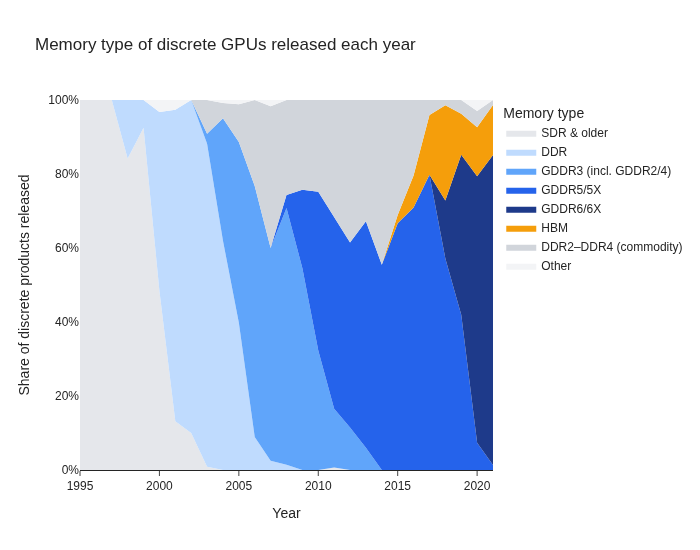

In [40]:
fig = px.area(
    df_mem_type,
    x='releaseYear',
    y='share',
    color='memGroup',
    category_orders={'memGroup': mem_group_order},
    color_discrete_map={
        'SDR & older': '#E5E7EB',
        'DDR': '#BFDBFE',
        'GDDR3 (incl. GDDR2/4)': '#60A5FA',
        'GDDR5/5X': '#2563EB',
        'GDDR6/6X': '#1E3A8A',
        'HBM': '#F59E0B',
        'DDR2–DDR4 (commodity)': '#D1D5DB',
        'Other': '#F3F4F6',
    },
    labels={
        'releaseYear': 'Year',
        'share': 'Share of discrete products released',
        'memGroup': 'Memory type',
    },
    title='Memory type of discrete GPUs released each year',
    height=550,
)

fig.for_each_trace(lambda trace: trace.update(fillcolor=trace.line.color))
fig.update_traces(line={'width': 0})
fig.update_yaxes(showline=False, tickformat='.0%', ticks='')
fig.update_layout(hovermode='x', yaxis_range=[0, 1])

fig.show()

In [41]:
df_hbm = df_discrete.query('memGroup == "HBM"') \
    .groupby('releaseYear', as_index=False) \
    .agg(num_products=('productName', 'count'), example=('productName', 'first'))

df_hbm.merge(df_mem_type.query('memGroup == "HBM"')[['releaseYear', 'share']], on='releaseYear').round(2)

,releaseYear,num_products,example,share
0,2015,3,Radeon R9 FURY,0.02
1,2016,8,FirePro S9300 X2,0.09
2,2017,16,Radeon Instinct MI25,0.16
3,2018,18,Quadro GV100,0.26
4,2019,9,Radeon Pro Vega 48,0.11
5,2020,9,A100 PCIe,0.13
6,2021,10,A100 PCIe 80 GB,0.14


- Each memory generation was the most common type for about five years: **SDR and older** in 1995–1999, **DDR** in 2000–2004 (peak 90%), and **GDDR3** in 2005–2009.
- **GDDR5 was on top for nine years (2010–2018)**, longer than any other memory type, and peaked at 80% of discrete products in 2017. **GDDR6/6X** took over in 2019 and reached 84% by 2021.
- **HBM** (stacked memory) first appeared in 2015 (Radeon R9 FURY) and peaked at 26% of discrete products in 2018 with 18 products. Early HBM products include consumer cards (Radeon R9 FURY, RX Vega 56/64), but from 2020 on HBM appears almost only on data-center and workstation parts. It did not replace GDDR in mainstream cards.
- The gray band shows low-end cards that used commodity DDR2/DDR3 memory. It was sizable from about 2006 to 2016 and nearly disappeared after 2017.


### Bus interface

In [42]:
def get_bus_group(bus):
    if bus.startswith('PCIe'):
        return bus.split(' x')[0]  # e.g., 'PCIe 3.0 x16' -> 'PCIe 3.0'
    if bus.startswith('AGP'):
        return 'AGP'
    if bus.startswith('PCI'):
        return 'PCI'
    if bus.startswith('MXM'):
        return 'MXM (mobile module)'
    return 'Other'


bus_group_order = ['PCI', 'AGP', 'PCIe 1.0', 'PCIe 2.0', 'PCIe 3.0', 'PCIe 4.0',
                   'MXM (mobile module)', 'Other']

df_discrete['busGroup'] = df_discrete['bus'].map(get_bus_group)

df_bus = pd.crosstab(df_discrete['releaseYear'], df_discrete['busGroup'], normalize='index') \
    .reset_index() \
    .melt(id_vars='releaseYear', var_name='busGroup', value_name='share')

df_bus_top = df_bus.loc[df_bus.groupby('releaseYear')['share'].idxmax()]
df_bus_first = df_discrete.groupby('busGroup', as_index=False).agg(first_year_in_data=('releaseYear', 'min'))

df_bus_top.groupby('busGroup', as_index=False).agg(
    first_year_on_top=('releaseYear', 'min'),
    last_year_on_top=('releaseYear', 'max'),
    years_on_top=('releaseYear', 'count'),
    peak_share=('share', 'max'),
).merge(df_bus_first, on='busGroup').sort_values('first_year_on_top').round(2)

,busGroup,first_year_on_top,last_year_on_top,years_on_top,peak_share,first_year_in_data
1,PCI,1995,1996,2,1.00,1995
0,AGP,1997,2003,7,0.92,1996
2,PCIe 1.0,2004,2007,4,0.79,2001
3,PCIe 2.0,2008,2012,5,0.83,2007
4,PCIe 3.0,2013,2019,7,0.85,2011
5,PCIe 4.0,2020,2021,2,0.81,2018


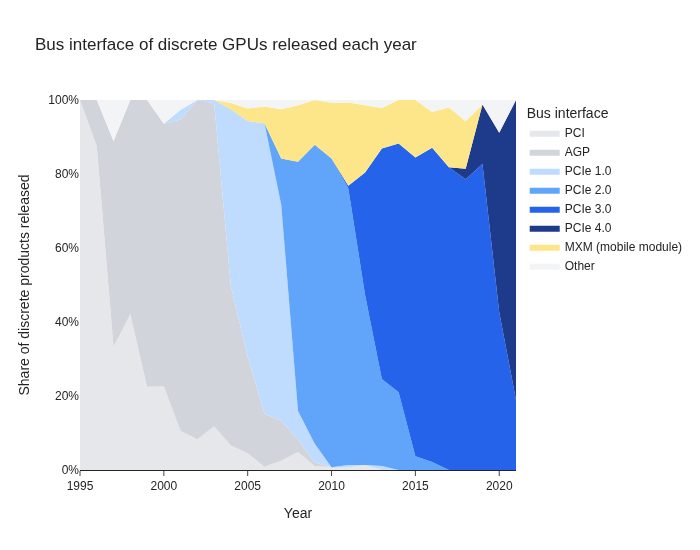

In [43]:
fig = px.area(
    df_bus,
    x='releaseYear',
    y='share',
    color='busGroup',
    category_orders={'busGroup': bus_group_order},
    color_discrete_map={
        'PCI': '#E5E7EB',
        'AGP': '#D1D5DB',
        'PCIe 1.0': '#BFDBFE',
        'PCIe 2.0': '#60A5FA',
        'PCIe 3.0': '#2563EB',
        'PCIe 4.0': '#1E3A8A',
        'MXM (mobile module)': '#FDE68A',
        'Other': '#F3F4F6',
    },
    labels={
        'releaseYear': 'Year',
        'share': 'Share of discrete products released',
        'busGroup': 'Bus interface',
    },
    title='Bus interface of discrete GPUs released each year',
    height=550,
)

fig.for_each_trace(lambda trace: trace.update(fillcolor=trace.line.color))
fig.update_traces(line={'width': 0})
fig.update_yaxes(showline=False, tickformat='.0%', ticks='')
fig.update_layout(hovermode='x', yaxis_range=[0, 1])

fig.show()

- **AGP was the main interface for seven years (1997–2003)**, peaking at 92% of discrete products. **PCIe 1.0 overtook it in 2004**, the first year PCIe cards appear in volume. (PCIe 1.0's first appearance in 2001 is an early outlier.)
- PCIe generations then took turns at the top: **PCIe 1.0 for four years (2004–2007), PCIe 2.0 for five years (2008–2012), PCIe 3.0 for seven years (2013–2019), and PCIe 4.0 from 2020** (81% of discrete products in 2021). PCIe 3.0's run was the longest of any PCIe generation, much like GDDR5's run among memory types.
- Each new PCIe generation took one to two years to go from its first appearance to the top (PCIe 2.0: 2007 → 2008, PCIe 3.0: 2011 → 2013, PCIe 4.0: 2018 → 2020).
- The yellow band is **MXM**, a module format for laptop GPUs. It was common from 2007 to 2018. In later years, mobile GPUs are listed with PCIe buses.


## 💻 Integrated vs. Discrete GPUs

Integrated GPUs (IGPs) live inside a CPU or chipset and share system memory. How much of each manufacturer's catalog is integrated (1995–2021)?

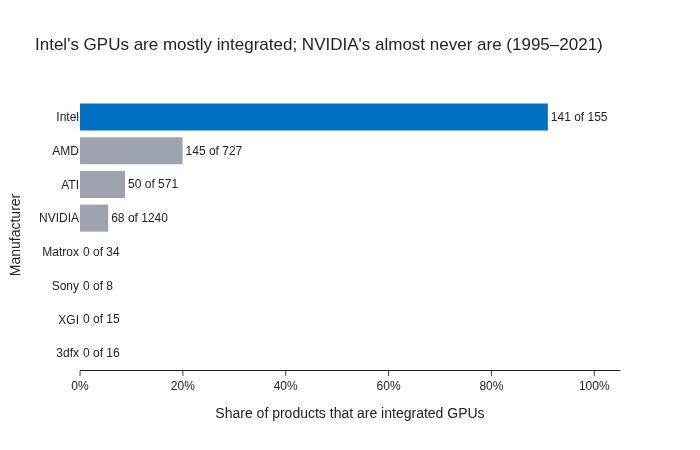

In [44]:
df_1995['isIntegrated'] = df_1995['igp'] == 'Yes'

df_igp = df_1995.groupby('manufacturer', as_index=False).agg(
    num_products=('productName', 'count'),
    num_integrated=('isIntegrated', 'sum'),
    share_integrated=('isIntegrated', 'mean'),
).sort_values('share_integrated')

fig = px.bar(
    df_igp,
    x='share_integrated',
    y='manufacturer',
    orientation='h',
    text=df_igp.apply(lambda row: f"{row['num_integrated']} of {row['num_products']}", axis=1),
    labels={
        'share_integrated': 'Share of products that are integrated GPUs',
        'manufacturer': 'Manufacturer',
    },
    title="Intel's GPUs are mostly integrated; NVIDIA's almost never are (1995–2021)",
    height=450,
)

fig.update_traces(
    marker_color=['#0071C5' if m == 'Intel' else '#9CA3AF' for m in df_igp['manufacturer']],
    marker_line_width=0,
    textposition='outside',
    cliponaxis=False,
)
fig.update_xaxes(tickformat='.0%', range=[0, 1.05])
fig.update_yaxes(showline=False, ticks='')

fig.show()

In [45]:
df_1995.query('manufacturer == "Intel" and igp == "No"') \
    .groupby('releaseYear', as_index=False) \
    .agg(
        num_products=('productName', 'count'),
        example_products=('productName', lambda names: ', '.join(names.head(3))),
    )

,releaseYear,num_products,example_products
0,1998,2,"i740, i740 8 MB"
1,1999,1,i752
2,2010,1,Aubrey Isle
3,2012,3,"Xeon Phi 3120A, Xeon Phi 5110P, Xeon Phi SE10X"
4,2013,3,"Xeon Phi 5120D, Xeon Phi 7120P, Xeon Phi 7120X"
5,2020,2,"H3C XG310, Iris Xe MAX Graphics"
6,2021,2,"Arctic Sound 1T, Arctic Sound 2T"


In [46]:
# Intel's Arc launch falls in the partial 2022 data that was set aside
df_partial.query('manufacturer == "Intel"') \
    .groupby('igp', as_index=False) \
    .agg(
        num_products=('productName', 'count'),
        example_products=('productName', lambda names: ', '.join(names.head(4))),
    )

,igp,num_products,example_products
0,No,9,"Arc A350M, Arc A370M, Arc A380, Arc A550M"
1,Yes,6,"Iris Xe Graphics 80EU, Iris Xe Graphics 96EU, ..."


- **Intel's GPUs are mostly integrated: 141 of 155 products (91%) from 1995–2021.** AMD's are about 20% integrated (145 of 727, mostly APUs). ATI's are 9% (50 of 571) and NVIDIA's 5.5% (68 of 1,240: chipset graphics and Tegra). Matrox, 3dfx, XGI, and Sony have no integrated products in the data.
- **Intel's discrete GPU history comes in short bursts:** the i740/i752 AGP cards (1998–1999), the Knights Ferry ("Aubrey Isle") and Xeon Phi compute cards (2010–2013; these are accelerators rather than graphics cards), the DG1-based H3C XG310 and Iris Xe MAX (2020), and Arctic Sound (2021).
- **Intel's Arc launch falls just outside the analysis window.** The partial 2022 data that was set aside lists 9 discrete Intel products (Arc A350M, A370M, A380, A550M, and others) alongside 6 integrated ones. A complete 2022–2023 dataset would likely show a bigger Intel share than the 15.1% peak in 2020, but this data can't confirm that.
- Product counts understate Intel's real-world presence. Intel ships integrated graphics in a huge number of PCs, but each integrated GPU appears here as a single SKU.


## Key Findings

- **The vendor field shrank to three companies.** In 2000, six manufacturers in the dataset released products. In every year from 2012 to 2021 there were exactly three: NVIDIA, AMD, and Intel. Vendors other than these three released 26.1% of products in 1995–1999 and only 0.4% in 2006–2010.
- **NVIDIA and AMD split the catalog, until NVIDIA pulled ahead at the end.** In every era from 2000 to 2021, NVIDIA released 42.1%–52.3% of products and AMD + ATI 43.5%–51.1%. In 2021 NVIDIA released 62.5% and AMD 27.3%. Intel peaked at 15.1% in 2020. Its Arc launch falls in the partial 2022 data.
- **Unified shaders replaced separate pixel/vertex shaders in about two years**, from 1.6% of products in 2006 to 95% in 2008 and 100% in 2009. The first unified design in the data is a console GPU (Xbox 360, 2005).
- **Shader counts doubled about every 3.2 years.** The median went from 144 shaders (2010) to 2,560 (2021). Only 25% of 2021 products had fewer than 1,000 shaders, compared with 92% in 2010.
- **Growth in graphics memory has slowed.** The median doubled every 1.7 years in 1995–2009 and every 3.1 years in 2010–2021 (p = 8.3e-06), and the result holds for any break year from 2006 to 2012. Meanwhile, the median memory bus stayed at 128 bits from 1999 to 2017.
- **Each technology generation has a typical lifespan.** Memory types stayed on top for about five years each, except GDDR5, which lasted nine (2010–2018). Bus interfaces show a similar pattern: AGP and PCIe 3.0 each lasted seven years, and each new PCIe generation went from first appearance to most common in one to two years.
- **Integrated graphics is mostly an Intel story.** 91% of Intel's products are integrated, compared with 20% for AMD and 5.5% for NVIDIA.


## Case Study Potential

**Verdict: Moderate.** The data is clean (once the right version is used), CC0-licensed, and about a topic students know. It produces crisp, checkable patterns: a two-year architecture switch, a statistically clear slowdown in memory growth, recurring technology-generation lifecycles, and vendor consolidation. The limit is that rows are product launches with no prices, unit sales, or performance figures. The most interesting business questions (market share, pricing, performance per dollar) can't be answered directly, and much of the story is descriptive technology history. Part of the hardware-trend material also overlaps with the sibling `cpu-gpu-chips` analysis.

**Suggested framing:** *You are a product planner at a PC/laptop maker (or a market analyst at a hardware retailer). How long does a memory or bus technology stay mainstream, and how quickly does a new one take over? When should the company plan for the next transition?* Students measure adoption speed and dominance periods from the product record and turn them into a planning rule of thumb (for example, "a new PCIe generation becomes the most common within one to two years of its first products").

**Analytics skills exercised:** data profiling (missing-value patterns that encode meaning, such as integrated GPUs), choosing complete-year cutoffs and spotting placeholder records, `groupby`/`crosstab` share-over-time analysis, log-scale growth and doubling-time regression with a structural break (interaction term, robustness to the break year), and categorical "dominant-type" analysis for technology transitions.

**Candidate student questions:**
1. How many manufacturers released products each year, and when did the field shrink to three? What do product counts miss about market share?
2. When did unified shaders become the majority of new products, and what kinds of products held out longest?
3. Has the doubling time of GPU memory changed? Test for a structural break and check whether your answer depends on the break year you choose.
4. How long did each memory type and bus interface stay most common, and how fast did each successor take over?
5. *(Optional data-validation warm-up)* Download the v7 file from the same Kaggle page and compare it with v6. Which columns can you trust?

**Main data limitations:** rows are SKUs, not sales or revenue, so "share" means share of product launches. Only eight manufacturers are covered. The analysis ends in 2021 because v6's 2022 data is partial and contains pre-launch placeholders, so the RTX 40 series, RDNA 3, and Intel Arc launches are outside the window. Release dates have year-level precision only. Shader counts are not comparable across vendors or architectures. TechPowerUp's coverage of OEM, mobile, and rebranded SKUs may vary over time, which affects product counts.
